# Figure 1 Trained Dataset Stats


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c
from violmulti.data.dataset_loader import DatasetLoader
import statsmodels.formula.api as smf
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

%load_ext autoreload
%autoreload 2

sns.set_context("notebook", rc={"font.size": 12, "axes.titlesize": 14, "axes.labelsize": 12, "axes.titleweight": "bold"})

# Load data
data_loader = DatasetLoader()
data = data_loader.load_new_trained()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Load Data


In [2]:
df = DatasetLoader().load_data()

DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W082', 'W083', 'W088', 'W089', 'W094']


# A- Time to Train


In [3]:
train_time_df = df.groupby(["animal_id"]).session.min().reset_index().rename(columns={"session": "train_time"})
train_time_df.head() 

,animal_id,train_time
0,W051,326
1,W060,248
2,W065,101
3,W066,286
4,W068,423


In [4]:
train_time_df.train_time.describe().reset_index()



,index,train_time
0,count,17.000000
1,mean,238.352941
2,std,113.632049
3,min,101.000000
4,25%,145.000000
5,50%,243.000000
6,75%,286.000000
7,max,481.000000


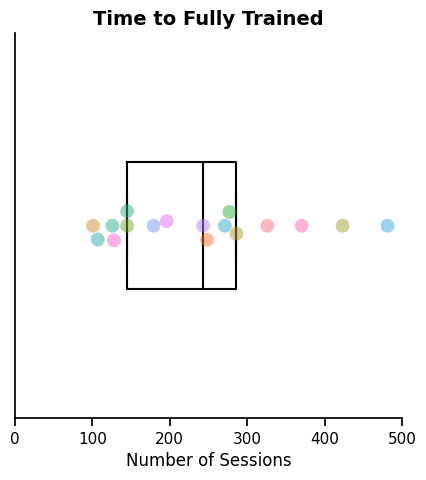

In [231]:
fig, ax = plt.subplots(figsize=(5,5))
sns.despine()

sns.boxplot(x="train_time", data=train_time_df, ax=ax, fill=False,
        showfliers=False,
        whis=0,
        width=0.33, color="k")
sns.swarmplot(x="train_time", data=train_time_df, ax=ax, size=10, alpha=0.5, hue="animal_id", legend=False)

ax.set(xlim= (0, None), xlabel="Number of Sessions")
ax.set_title("Time to Fully Trained", fontweight="bold")

#get rid of xtick
ax.set_yticks([])

fig.savefig("figures/fig1a_time_to_train_boxswarm.png", dpi=300, bbox_inches="tight")




# B Choice Distributions


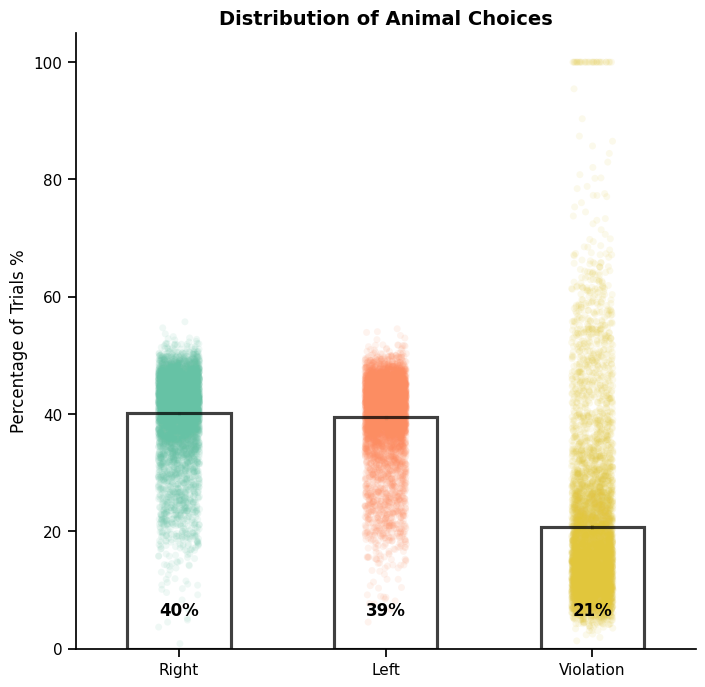

In [233]:

choice_dist_df = df.groupby(["animal_id", "session"]).choice.value_counts(normalize=True).reset_index()
choice_dist_df["Choice"] = choice_dist_df["choice"].map({0: "Left", 1: "Right", 2: "Violation"})
choice_dist_df["percentage"] = choice_dist_df["proportion"] * 100
choice_dist_df["percentage"] = choice_dist_df["percentage"].round(2)
choice_dist_df.head()
l = sns.color_palette("Set2",3)[0]
r = sns.color_palette("Set2",3)[1]
v = c.VIOLATION_COLOR
pal = [l, r, v]

fig, ax = plt.subplots(figsize=(8,8))
sns.despine()

sns.barplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, width=0.5, fill=False, zorder=10, errorbar="se", color="k", alpha =0.75)
sns.stripplot(x="Choice", y="percentage", data=choice_dist_df, ax=ax, alpha=0.10, palette=pal, hue="Choice")
ax.set(xlabel="", ylabel="Percentage of Trials %")
ax.set_title("Distribution of Animal Choices", fontweight="bold")

# Add text labels for each Choice group at y=5
for choice in choice_dist_df["Choice"].unique():
    percentage = choice_dist_df[choice_dist_df["Choice"] == choice]["percentage"].mean()
    ax.text(x=choice, y=5, s=f"{percentage:.0f}%", ha='center', va='bottom', fontweight='bold')

fig.savefig("figures/fig1b_choice_distribution.png", dpi=300, bbox_inches="tight")

# C,D,E Hit Rate, Trial Rate, and Violation Rate


In [24]:
df.head()

,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,animal_id_session
0,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000000,3,0.5,NaN,2,326,326.0,0.0,1,W051_s326
1,W051,2014-07-17,327,19,4,60.0,68.0,NaN,1,False,...,18.000001,3,0.5,NaN,2,326,326.0,0.0,2,W051_s326
2,W051,2014-07-17,327,19,4,76.0,68.0,NaN,1,False,...,18.000004,3,0.5,NaN,2,326,326.0,0.0,3,W051_s326
3,W051,2014-07-17,327,19,4,68.0,76.0,1.0,0,False,...,18.000014,3,0.5,NaN,0,326,326.0,0.0,4,W051_s326
4,W051,2014-07-17,327,19,4,84.0,76.0,1.0,0,False,...,18.000033,3,0.5,NaN,1,326,326.0,0.0,5,W051_s326


In [234]:
perf_agg_df = df.groupby(["animal_id", "session"]).agg({"hit": "mean", "trial": "max", "violation": "mean"}).reset_index()

In [237]:
def plot_histogram(x, color,df=perf_agg_df, **kwargs):
    fig, ax = plt.subplots(figsize=(6,4))
    sns.despine()

    sns.histplot(x=x, data=df, ax=ax, color=color, element="step", alpha = 0.5,**kwargs)

    median_value = df[x].median()
    ax.axvline(median_value, color=color, linestyle="--", label=f"Median: {median_value:.2f}")

    return fig, ax

## Trial


,index,trial
0,count,5786.000000
1,mean,370.683546
2,std,157.759392
3,min,1.000000
4,25%,269.000000
5,50%,354.000000
6,75%,448.000000
7,max,1494.000000


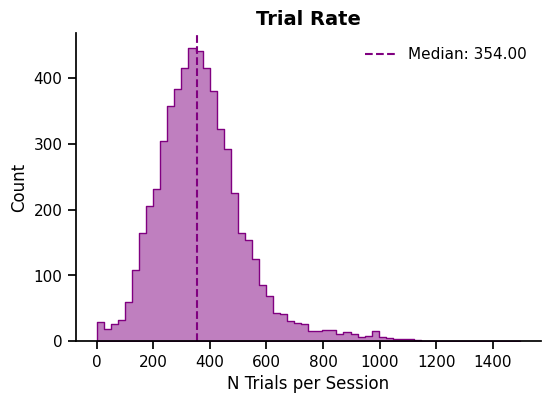

In [239]:
fig, ax = plot_histogram("trial", c.N_TRIAL_COLOR, binwidth=25)
ax.set(xlabel="N Trials per Session")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Trial Rate", fontweight="bold")
fig.savefig("figures/fig1c_trial_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.trial.describe().reset_index()


## Hit


,index,hit
0,count,5754.000000
1,mean,0.816947
2,std,0.062768
3,min,0.000000
4,25%,0.776710
5,50%,0.814168
6,75%,0.858427
7,max,1.000000


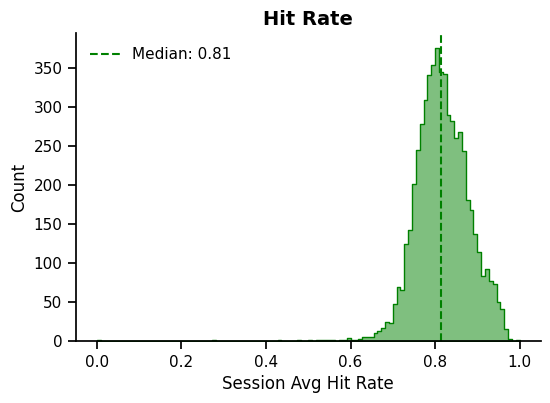

In [240]:
fig, ax = plot_histogram("hit", c.HIT_COLOR)
ax.set(xlabel="Session Avg Hit Rate")
ax.legend(loc="upper left", frameon=False)
ax.set_title("Hit Rate", fontweight="bold")
fig.savefig("figures/fig1d_hit_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.hit.describe().reset_index()

## Violation


,index,violation
0,count,5786.000000
1,mean,0.208105
2,std,0.144336
3,min,0.013453
4,25%,0.114872
5,50%,0.164000
6,75%,0.247375
7,max,1.000000


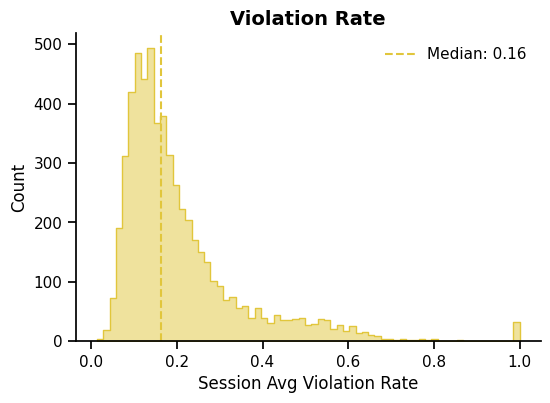

In [241]:
fig, ax = plot_histogram("violation", c.VIOLATION_COLOR)
ax.set(xlabel="Session Avg Violation Rate")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Violation Rate", fontweight="bold")
fig.savefig("figures/fig1e_violation_rate.png", dpi=300, bbox_inches="tight")
perf_agg_df.violation.describe().reset_index()

# F Trained: Violation Rate by Hit Rate


In [261]:
ylim=(0, 0.9)
xlim=(0.5, 1)

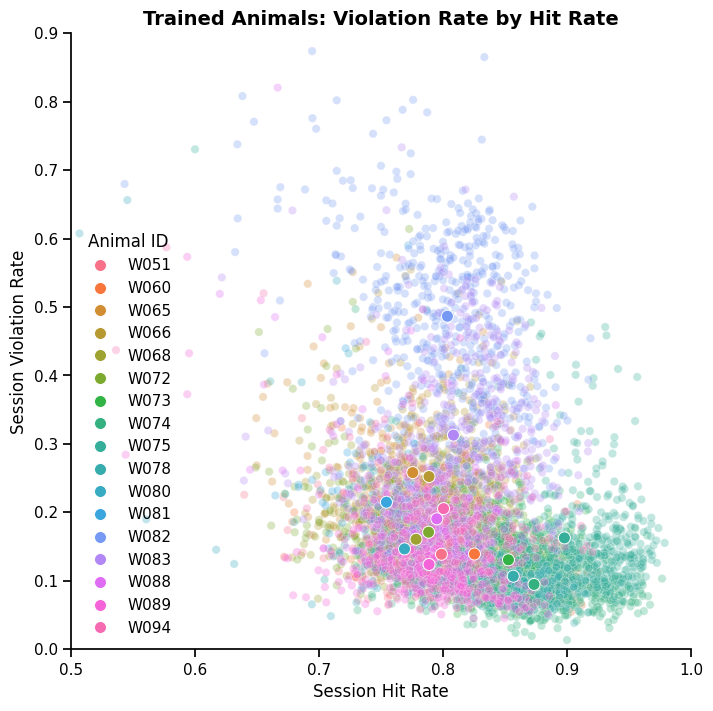

In [262]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_df.query("trial > 50 and violation < 0.9")
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit": "mean", "violation": "mean", "trial" : "mean"}).reset_index()

sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate", ylabel="Session Violation Rate", xlim=xlim, ylim=ylim)
ax.set_title("Trained Animals: Violation Rate by Hit Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False)
fig.savefig("figures/fig1f_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [263]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ hit", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 5734    Method:             REML     
No. Groups:       17      Scale:              0.0050   
Min. group size:  114     Log-Likelihood:     6976.7826
Max. group size:  552     Converged:          Yes      
Mean group size:  337.3                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.507    0.028  18.260 0.000  0.452  0.561
hit         -0.387    0.020 -18.879 0.000 -0.427 -0.347
Group Var    0.008    0.042                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


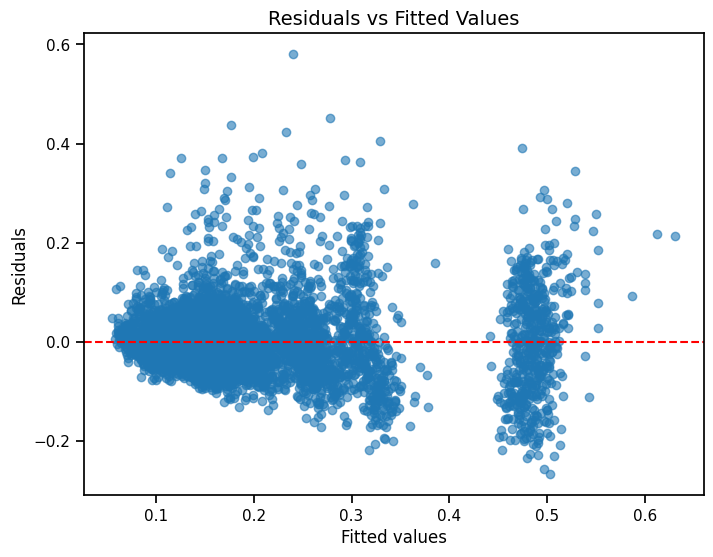

In [264]:
# Extract fitted values and residuals
fitted = result.fittedvalues
residuals = result.resid

plt.figure(figsize=(8, 6))
plt.scatter(fitted, residuals, alpha=0.6)
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.axhline(0, color="red", linestyle="--")
plt.show()

In [265]:

# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['violation'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['violation'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.7052904981888737
Marginal R-squared: 0.06018615109464254


In [266]:
# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['hit']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.08794115601564045


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[(0.7, 1.0), (0.0, 0.55)]

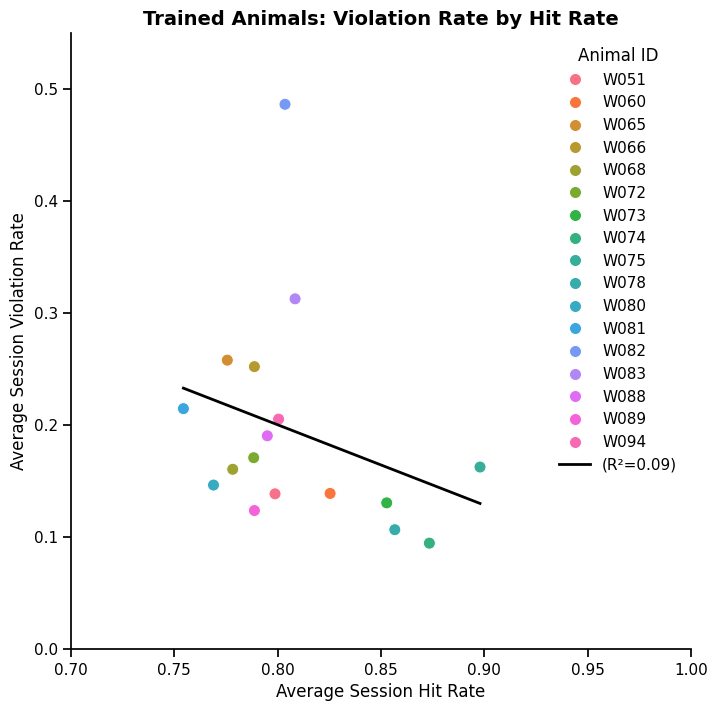

In [267]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate", ylabel="Average Session Violation Rate")
ax.set_title("Trained Animals: Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit'].min(), plot_df_by_animal['hit'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")


fig.savefig("figures/fig1f_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")
ax.set(xlim=(0.7, 1), ylim=(0, 0.55))

# G Learning: Violation Rate by Hit Rate


In [268]:
ldf = DatasetLoader(data_type="new_all").load_data()
#query for sessions below the time to train sesionf or each animal


DataLoader: Loading data for animal ids:  ['W051', 'W060', 'W065', 'W066', 'W068', 'W072', 'W073', 'W074', 'W075', 'W078', 'W080', 'W081', 'W082', 'W083', 'W088', 'W089', 'W094']


In [269]:
# Merge ldf with train_time_df to get the train_time for each animal
ldf_merged = ldf.merge(train_time_df, on='animal_id')
# Group by animal_id and filter each group based on train_time
ldf_filt = ldf_merged.query("training_stage >= 3").groupby('animal_id').apply(
    lambda group: group[group['session_file_counter'] < group['train_time'].iloc[0]]
).reset_index(drop=True)

ldf_filt.head()

/var/folders/__/8jn6qz211155h1xb451s5zcr0000gn/T/ipykernel_10953/536801089.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ldf_filt = ldf_merged.query("training_stage >= 3").groupby('animal_id').apply(


,animal_id,session_date,session_file_counter,rig_id,training_stage,s_a,s_b,hit,violation,trial_not_started,...,r_water_vol,antibias_beta,antibias_right_prob,using_psychometric_pairs,choice,session,session_relative_to_old,n_prev_trial_not_started,trial,train_time
0,W051,2013-08-15,30,2,3,68.0,60.0,NaN,1,False,...,18.000000,2,0.5,NaN,2,30,30.0,0.0,1,326
1,W051,2013-08-15,30,2,3,68.0,76.0,NaN,1,False,...,18.000001,2,0.5,NaN,2,30,30.0,0.0,2,326
2,W051,2013-08-15,30,2,3,68.0,60.0,NaN,1,False,...,18.000004,2,0.5,NaN,2,30,30.0,0.0,3,326
3,W051,2013-08-15,30,2,3,68.0,76.0,NaN,1,False,...,18.000014,2,0.5,NaN,2,30,30.0,0.0,4,326
4,W051,2013-08-15,30,2,3,76.0,68.0,NaN,1,False,...,18.000033,2,0.5,NaN,2,30,30.0,0.0,5,326


In [270]:
perf_agg_ldf = ldf_filt.groupby(["animal_id", "session"]).agg({"hit": "mean", "trial": "max", "violation": "mean"}).reset_index()
xlim=(0.1, 1)
ylim=(0, 0.9)

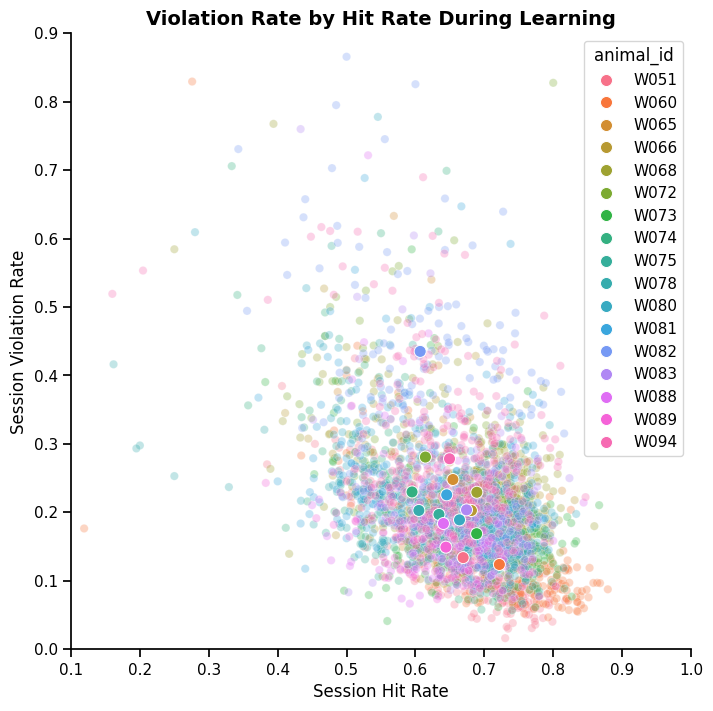

In [271]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

plot_df_all = perf_agg_ldf.query("trial > 50 and violation < 0.9")
plot_df_by_animal = plot_df_all.groupby("animal_id").agg({"hit": "mean", "violation": "mean", "trial" : "mean"}).reset_index()

sns.scatterplot(x="hit", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Hit Rate", ylabel="Session Violation Rate")
ax.set_title("Violation Rate by Hit Rate During Learning", fontweight="bold")
ax.set(xlim=xlim, ylim=ylim)

# ax.legend(title="Animal ID", frameon=False)
fig.savefig("figures/fig1g_learning_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")

In [272]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ hit", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 3293    Method:             REML     
No. Groups:       17      Scale:              0.0061   
Min. group size:  73      Log-Likelihood:     3666.7953
Max. group size:  438     Converged:          Yes      
Mean group size:  193.7                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.484    0.019  25.865 0.000  0.448  0.521
hit         -0.411    0.016 -26.454 0.000 -0.442 -0.381
Group Var    0.004    0.019                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [273]:
# Using the fitted values from the model (includes fixed and random effects)
r2_conditional = r2_score(plot_df_all['violation'], result.fittedvalues)
print("Conditional R-squared:", r2_conditional)

# Extract fixed effect parameters
fixed_intercept = result.fe_params['Intercept']
fixed_slope = result.fe_params['hit']

# Compute predictions using only fixed effects
pred_fixed = fixed_intercept + fixed_slope * plot_df_all['hit']

# Compute marginal R² as the squared correlation between observed values and fixed-effect predictions
r2_marginal = r2_score(plot_df_all['violation'], pred_fixed)
print("Marginal R-squared:", r2_marginal)

Conditional R-squared: 0.45294487338753286
Marginal R-squared: 0.1777598842938608


In [274]:
model = LinearRegression()
X = plot_df_by_animal[['hit']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.2979785921090391


/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


[(0.5, 0.8), (0.0, 0.5)]

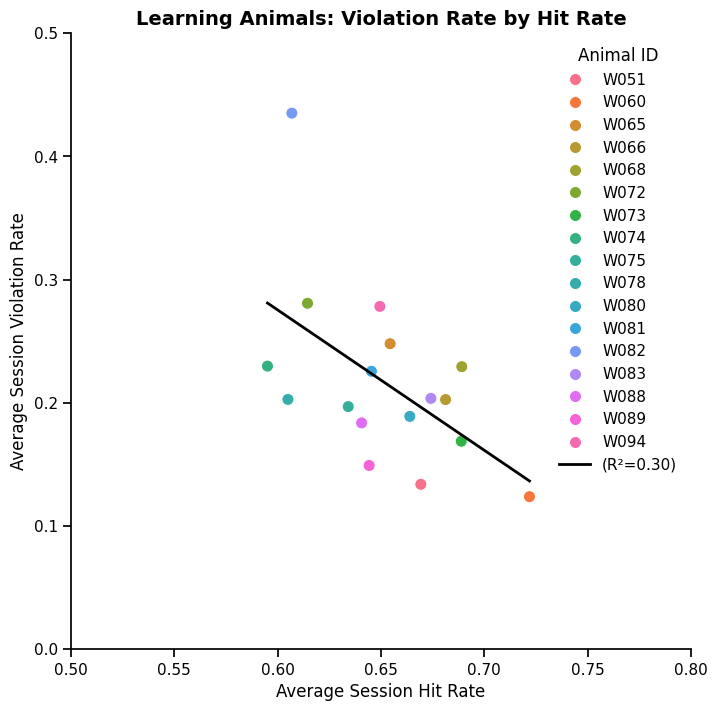

In [275]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="hit", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Average Session Hit Rate", ylabel="Average Session Violation Rate")
ax.set_title("Learning Animals: Violation Rate by Hit Rate", fontweight="bold")

# Plot the linear regression line in black
# Create x-values spanning the range of hit rates
x_vals = np.linspace(plot_df_by_animal['hit'].min(), plot_df_by_animal['hit'].max(), 100)
# Predict violation rates using the regression model
y_vals = model.predict(x_vals.reshape(-1, 1))
# Plot the regression line
ax.plot(x_vals, y_vals, color='black', linewidth=2, label=f"(R²={r2_aggregated:.2f})")

# Update the legend to include the regression line
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles, labels=labels, title="Animal ID", frameon=False, loc="upper right")

fig.savefig("figures/fig1g_learning_violation_rate_by_hit_rate_by_animal.png", dpi=300, bbox_inches="tight")
ax.set(xlim=(0.5, 0.8), ylim=(0, 0.5))

---

# EXTRA: Violation Rate by N Trials


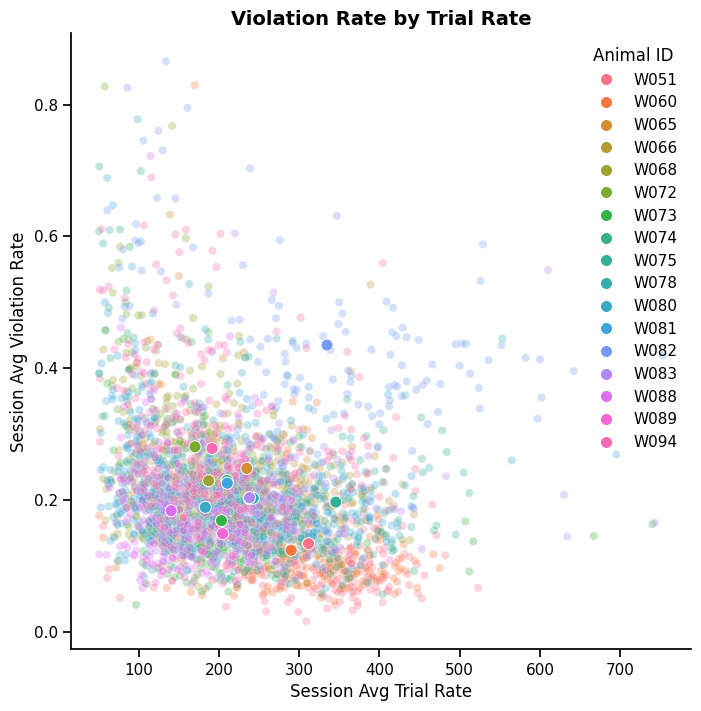

In [276]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="trial", y="violation", data=plot_df_all, ax=ax, hue="animal_id", alpha=0.3, legend=False, palette=palette)
sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False)
# fig.savefig("figures/fig1e_violation_rate_by_trial_rate.png", dpi=300, bbox_inches="tight")

In [277]:
# Define the model with animal_id as a grouping (random intercept)
model = smf.mixedlm("violation ~ trial", data=plot_df_all, groups=plot_df_all["animal_id"])

# Fit the model
result = model.fit()

# Print the model summary
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: violation
No. Observations: 3293    Method:             REML     
No. Groups:       17      Scale:              0.0069   
Min. group size:  73      Log-Likelihood:     3478.3248
Max. group size:  438     Converged:          Yes      
Mean group size:  193.7                                
-------------------------------------------------------
            Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept    0.283    0.019  15.113 0.000  0.247  0.320
trial       -0.000    0.000 -16.826 0.000 -0.000 -0.000
Group Var    0.006    0.025                            



/Users/jessbreda/anaconda3/envs/viol-multi/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


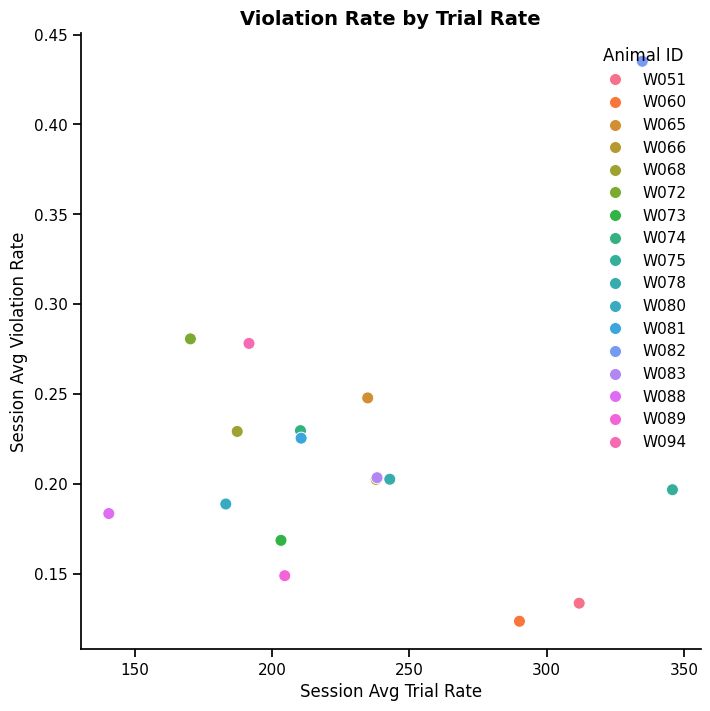

In [278]:
fig, ax = plt.subplots(figsize=(8,8))
sns.despine()
palette = sns.color_palette("husl", 17)

sns.scatterplot(x="trial", y="violation", data=plot_df_by_animal, ax=ax, hue="animal_id", alpha=1, s=75, palette=palette)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")

ax.legend(title="Animal ID", frameon=False, loc="upper right")
# fig.savefig("figures/fig1e_violation_rate_by_hit_rate.png", dpi=300, bbox_inches="tight")
# ax.set(xlim=(0.7, 1), ylim=(0, 0.55))

In [279]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
# Fit a simple linear regression model
model = LinearRegression()
X = plot_df_by_animal[['trial']]
y = plot_df_by_animal['violation']
model.fit(X, y)

# Generate predictions and compute R-squared
y_pred = model.predict(X)
r2_aggregated = r2_score(y, y_pred)
print("R-squared on aggregated data:", r2_aggregated)

R-squared on aggregated data: 0.01470364006672753


Text(0.5, 1.0, 'Violation Rate by Trial Rate')

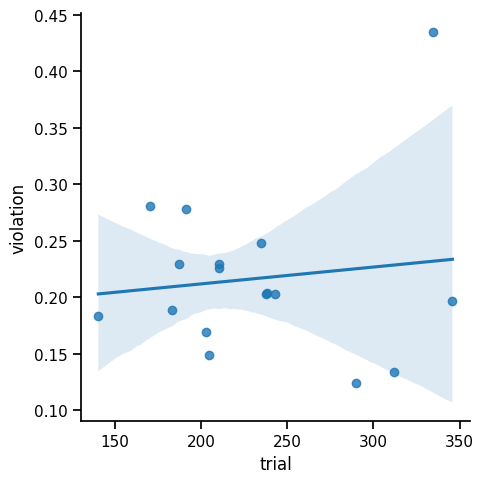

In [280]:
sns.lmplot(x="trial", y="violation", data=plot_df_by_animal)
ax.set(xlabel="Session Avg Trial Rate", ylabel="Session Avg Violation Rate")
ax.set_title("Violation Rate by Trial Rate", fontweight="bold")
